#PAKISTAN AIR QUALITY FROM 2015-2025 EXPLORATORY DATA ANALYSIS 

## 1: DISCOVERING DATA

In [1]:
#Importing Libararies 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
#Importing dataset 
df= pd.read_csv(r"C:\Users\welcome\OneDrive\Desktop\Pakistan_air_quality_2015-2025\pakistan_air_quality_monthly_2015_2025.csv")
df.head()

,year,month,month_name,city,province,region,latitude,longitude,population_millions,pm25_ugm3,...,who_guideline_ratio,is_smog_season,is_crop_burning_season,is_monsoon_season,season,covid_lockdown_period,data_source,data_quality,pakistan_national_avg_pm25,pakistan_global_rank
0,2015,1,January,Faisalabad,Punjab,Central Punjab,31.4187,73.0791,3.8,266.3,...,53.3,1,0,0,Winter (Smog Season),0,IQAir World Air Quality Report 2018-2025 / IQA...,Estimated (pre-monitoring era),NaN,NaN
1,2015,2,February,Faisalabad,Punjab,Central Punjab,31.4187,73.0791,3.8,237.7,...,47.5,1,0,0,Winter (Smog Season),0,IQAir World Air Quality Report 2018-2025 / IQA...,Estimated (pre-monitoring era),NaN,NaN
2,2015,3,March,Faisalabad,Punjab,Central Punjab,31.4187,73.0791,3.8,145.0,...,29.0,0,0,0,Spring,0,IQAir World Air Quality Report 2018-2025 / IQA...,Estimated (pre-monitoring era),NaN,NaN
3,2015,4,April,Faisalabad,Punjab,Central Punjab,31.4187,73.0791,3.8,74.7,...,14.9,0,0,0,Spring,0,IQAir World Air Quality Report 2018-2025 / IQA...,Estimated (pre-monitoring era),NaN,NaN
4,2015,5,May,Faisalabad,Punjab,Central Punjab,31.4187,73.0791,3.8,59.6,...,11.9,0,0,0,Summer/Monsoon,0,IQAir World Air Quality Report 2018-2025 / IQA...,Estimated (pre-monitoring era),NaN,NaN


In [3]:
#Shape of Dataset
df.shape

(1320, 23)

In [4]:
#Size of dataset
df.size

30360

In [5]:
#Details of dataset 
df.info

<bound method DataFrame.info of       year  month month_name        city province          region  latitude  \
0     2015      1    January  Faisalabad   Punjab  Central Punjab   31.4187   
1     2015      2   February  Faisalabad   Punjab  Central Punjab   31.4187   
2     2015      3      March  Faisalabad   Punjab  Central Punjab   31.4187   
3     2015      4      April  Faisalabad   Punjab  Central Punjab   31.4187   
4     2015      5        May  Faisalabad   Punjab  Central Punjab   31.4187   
...    ...    ...        ...         ...      ...             ...       ...   
1315  2025      8     August  Rawalpindi   Punjab    North Punjab   33.6007   
1316  2025      9  September  Rawalpindi   Punjab    North Punjab   33.6007   
1317  2025     10    October  Rawalpindi   Punjab    North Punjab   33.6007   
1318  2025     11   November  Rawalpindi   Punjab    North Punjab   33.6007   
1319  2025     12   December  Rawalpindi   Punjab    North Punjab   33.6007   

      longitude  po

In [6]:
# Fiding null values in columns
df.isnull().sum()

year                            0
month                           0
month_name                      0
city                            0
province                        0
region                          0
latitude                        0
longitude                       0
population_millions             0
pm25_ugm3                       0
aqi_us                          0
aqi_category                    0
annual_pm25_avg_ugm3            0
who_guideline_ratio             0
is_smog_season                  0
is_crop_burning_season          0
is_monsoon_season               0
season                          0
covid_lockdown_period           0
data_source                     0
data_quality                    0
pakistan_national_avg_pm25    360
pakistan_global_rank          360
dtype: int64

In [7]:
#Columns Names 
df.columns

Index(['year', 'month', 'month_name', 'city', 'province', 'region', 'latitude',
       'longitude', 'population_millions', 'pm25_ugm3', 'aqi_us',
       'aqi_category', 'annual_pm25_avg_ugm3', 'who_guideline_ratio',
       'is_smog_season', 'is_crop_burning_season', 'is_monsoon_season',
       'season', 'covid_lockdown_period', 'data_source', 'data_quality',
       'pakistan_national_avg_pm25', 'pakistan_global_rank'],
      dtype='str')

In [8]:
#checking duplicates
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1315    False
1316    False
1317    False
1318    False
1319    False
Length: 1320, dtype: bool

In [9]:
#Data type of variables 
df.dtypes

year                            int64
month                           int64
month_name                        str
city                              str
province                          str
region                            str
latitude                      float64
longitude                     float64
population_millions           float64
pm25_ugm3                     float64
aqi_us                          int64
aqi_category                      str
annual_pm25_avg_ugm3          float64
who_guideline_ratio           float64
is_smog_season                  int64
is_crop_burning_season          int64
is_monsoon_season               int64
season                            str
covid_lockdown_period           int64
data_source                       str
data_quality                      str
pakistan_national_avg_pm25    float64
pakistan_global_rank          float64
dtype: object

##DATA STRUCTURING AND CLEANING 

In [10]:
df.describe()

,year,month,latitude,longitude,population_millions,pm25_ugm3,aqi_us,annual_pm25_avg_ugm3,who_guideline_ratio,is_smog_season,is_crop_burning_season,is_monsoon_season,covid_lockdown_period,pakistan_national_avg_pm25,pakistan_global_rank
count,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,960.000000,960.000000
mean,2020.000000,6.500000,30.706130,71.307800,4.790000,73.991288,143.169697,73.973636,14.797955,0.416667,0.083333,0.225000,0.030303,70.535000,2.375000
std,3.163476,3.453361,3.074692,2.702904,5.192044,53.462290,53.090964,30.867629,10.693332,0.493193,0.276490,0.417741,0.171485,5.897765,0.696333
min,2015.000000,1.000000,24.860700,66.975000,1.100000,11.700000,49.000000,30.500000,2.300000,0.000000,0.000000,0.000000,0.000000,59.000000,1.000000
25%,2017.000000,3.750000,30.179800,68.357800,2.000000,34.300000,97.750000,48.100000,6.875000,0.000000,0.000000,0.000000,0.000000,67.752500,2.000000
50%,2020.000000,6.500000,31.469550,72.286400,2.300000,58.000000,152.000000,60.700000,11.600000,0.000000,0.000000,0.000000,0.000000,71.500000,2.500000
75%,2023.000000,9.250000,33.600700,73.079100,3.800000,92.700000,170.000000,105.000000,18.500000,1.000000,0.000000,0.000000,0.000000,73.842500,3.000000
max,2025.000000,12.000000,34.015100,74.358700,16.100000,266.300000,317.000000,145.000000,53.300000,1.000000,1.000000,1.000000,1.000000,80.100000,3.000000


In [11]:
#Removing Unnecessary columns 
df= df.drop(
    columns=['pakistan_national_avg_pm25', 'pakistan_global_rank'],
    errors= 'ignore'
    )
#Columns after removal 
df.columns
df.isnull().sum()

year                      0
month                     0
month_name                0
city                      0
province                  0
region                    0
latitude                  0
longitude                 0
population_millions       0
pm25_ugm3                 0
aqi_us                    0
aqi_category              0
annual_pm25_avg_ugm3      0
who_guideline_ratio       0
is_smog_season            0
is_crop_burning_season    0
is_monsoon_season         0
season                    0
covid_lockdown_period     0
data_source               0
data_quality              0
dtype: int64

In [12]:
df['city'].unique()

<ArrowStringArray>
['Faisalabad', 'Gujranwala',  'Hyderabad',  'Islamabad',    'Karachi',
     'Lahore',     'Multan',   'Peshawar',     'Quetta', 'Rawalpindi']
Length: 10, dtype: str

In [13]:
df['month_name'].unique()

<ArrowStringArray>
[  'January',  'February',     'March',     'April',       'May',      'June',
      'July',    'August', 'September',   'October',  'November',  'December']
Length: 12, dtype: str

In [14]:
df['month'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

In [15]:
df['longitude'].unique()

array([73.0791, 74.1945, 68.3578, 73.0479, 67.0011, 74.3587, 71.4711,
       71.5249, 66.975 , 73.0679])

In [16]:
df['city'].value_counts()

city
Faisalabad    132
Gujranwala    132
Hyderabad     132
Islamabad     132
Karachi       132
Lahore        132
Multan        132
Peshawar      132
Quetta        132
Rawalpindi    132
Name: count, dtype: int64

In [17]:
df['month'].value_counts()

month
1     110
2     110
3     110
4     110
5     110
6     110
7     110
8     110
9     110
10    110
11    110
12    110
Name: count, dtype: int64

In [18]:
df['province'].value_counts()

province
Punjab                         660
Sindh                          264
Islamabad Capital Territory    132
Khyber Pakhtunkhwa             132
Balochistan                    132
Name: count, dtype: int64

In [19]:
df['month_name'].value_counts()

month_name
January      110
February     110
March        110
April        110
May          110
June         110
July         110
August       110
September    110
October      110
November     110
December     110
Name: count, dtype: int64

In [20]:
df['region'].value_counts()

region
North Punjab      396
Central Punjab    132
Sindh             132
North             132
Coastal South     132
South Punjab      132
Northwest         132
Southwest         132
Name: count, dtype: int64

In [21]:
df['season'].value_counts()

season
Summer/Monsoon          440
Winter (Smog Season)    330
Post-Monsoon            330
Spring                  220
Name: count, dtype: int64

In [22]:
df['aqi_category'].value_counts()

aqi_category
Unhealthy                         513
Moderate                          343
Unhealthy for Sensitive Groups    290
Very Unhealthy                    170
Hazardous                           3
Good                                1
Name: count, dtype: int64

In [23]:
df['population_millions'].value_counts()

population_millions
2.3     396
3.8     132
1.8     132
2.2     132
16.1    132
14.0    132
2.0     132
1.1     132
Name: count, dtype: int64

In [24]:
df['longitude'].value_counts()

longitude
73.0791    132
74.1945    132
68.3578    132
73.0479    132
67.0011    132
74.3587    132
71.4711    132
71.5249    132
66.9750    132
73.0679    132
Name: count, dtype: int64

In [25]:
df['latitude'].value_counts()

latitude
31.4187    132
32.1877    132
25.3960    132
33.6844    132
24.8607    132
31.5204    132
30.1978    132
34.0151    132
30.1798    132
33.6007    132
Name: count, dtype: int64

##DATA VALIDATION

In [26]:
#Checks duplicated data
df.duplicated().sum()

np.int64(0)

In [27]:
#Checks data types of new columns
df.dtypes

year                        int64
month                       int64
month_name                    str
city                          str
province                      str
region                        str
latitude                  float64
longitude                 float64
population_millions       float64
pm25_ugm3                 float64
aqi_us                      int64
aqi_category                  str
annual_pm25_avg_ugm3      float64
who_guideline_ratio       float64
is_smog_season              int64
is_crop_burning_season      int64
is_monsoon_season           int64
season                        str
covid_lockdown_period       int64
data_source                   str
data_quality                  str
dtype: object

In [28]:
#Numerical summary 
df.describe()

,year,month,latitude,longitude,population_millions,pm25_ugm3,aqi_us,annual_pm25_avg_ugm3,who_guideline_ratio,is_smog_season,is_crop_burning_season,is_monsoon_season,covid_lockdown_period
count,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000
mean,2020.000000,6.500000,30.706130,71.307800,4.790000,73.991288,143.169697,73.973636,14.797955,0.416667,0.083333,0.225000,0.030303
std,3.163476,3.453361,3.074692,2.702904,5.192044,53.462290,53.090964,30.867629,10.693332,0.493193,0.276490,0.417741,0.171485
min,2015.000000,1.000000,24.860700,66.975000,1.100000,11.700000,49.000000,30.500000,2.300000,0.000000,0.000000,0.000000,0.000000
25%,2017.000000,3.750000,30.179800,68.357800,2.000000,34.300000,97.750000,48.100000,6.875000,0.000000,0.000000,0.000000,0.000000
50%,2020.000000,6.500000,31.469550,72.286400,2.300000,58.000000,152.000000,60.700000,11.600000,0.000000,0.000000,0.000000,0.000000
75%,2023.000000,9.250000,33.600700,73.079100,3.800000,92.700000,170.000000,105.000000,18.500000,1.000000,0.000000,0.000000,0.000000
max,2025.000000,12.000000,34.015100,74.358700,16.100000,266.300000,317.000000,145.000000,53.300000,1.000000,1.000000,1.000000,1.000000


In [29]:
#Checks missing values 
df.isnull().sum()

year                      0
month                     0
month_name                0
city                      0
province                  0
region                    0
latitude                  0
longitude                 0
population_millions       0
pm25_ugm3                 0
aqi_us                    0
aqi_category              0
annual_pm25_avg_ugm3      0
who_guideline_ratio       0
is_smog_season            0
is_crop_burning_season    0
is_monsoon_season         0
season                    0
covid_lockdown_period     0
data_source               0
data_quality              0
dtype: int64

In [30]:
#Checks minimum year limit
df['year'].min()

np.int64(2015)

In [31]:
#Checks maximum year limit
df['year'].max()

np.int64(2025)

##NUMERICAL FEATURES

In [32]:
#Finding numerical features
numerical_features= [
    'pm25_ugm3',
    'aqi_us',
    'aqi_category',
    'annual_pm25_avg_ugm3', 
    'who_guideline_ratio',
    'population_millions'
]
df[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
pm25_ugm3,1320.0,73.991288,53.462290,11.7,34.300,58.0,92.7,266.3
aqi_us,1320.0,143.169697,53.090964,49.0,97.750,152.0,170.0,317.0
annual_pm25_avg_ugm3,1320.0,73.973636,30.867629,30.5,48.100,60.7,105.0,145.0
who_guideline_ratio,1320.0,14.797955,10.693332,2.3,6.875,11.6,18.5,53.3
population_millions,1320.0,4.790000,5.192044,1.1,2.000,2.3,3.8,16.1


In [33]:
#which city has the highestand lowest aqi?
df.groupby('city')['aqi_us'].agg(['mean', 'min', 'max', 'median']).sort_values('mean', ascending= False)

,mean,min,max,median
city,,,,
Faisalabad,190.090909,108,317,173.5
Gujranwala,181.727273,108,271,170.0
Multan,174.250000,98,258,166.0
Lahore,170.818182,97,293,166.5
Peshawar,135.954545,72,194,149.0
Quetta,128.015152,73,176,134.5
Hyderabad,118.856061,63,177,117.0
Rawalpindi,117.696970,57,176,109.0
Karachi,109.022727,54,173,100.5


In [34]:
#which province has the highest aqi?
df.groupby('province')['aqi_us'].mean().sort_values(ascending= False)

province
Punjab                         166.916667
Khyber Pakhtunkhwa             135.954545
Balochistan                    128.015152
Sindh                          113.939394
Islamabad Capital Territory    105.265152
Name: aqi_us, dtype: float64

In [35]:
df.groupby('season')['aqi_us'].mean().sort_values(ascending= False)

season
Winter (Smog Season)    196.875758
Post-Monsoon            159.078788
Spring                  128.772727
Summer/Monsoon           98.156818
Name: aqi_us, dtype: float64

In [36]:
df.groupby('month_name')['aqi_us'].mean().sort_values(ascending= False)

month_name
January      203.009091
December     196.536364
February     191.081818
November     187.400000
October      160.545455
March        149.190909
September    129.290909
August       114.236364
April        108.354545
July          99.263636
May           91.145455
June          87.981818
Name: aqi_us, dtype: float64

In [37]:
df.groupby('year')['aqi_us'].mean().sort_values(ascending= False)

year
2025    150.291667
2015    147.508333
2017    147.441667
2018    146.900000
2024    146.125000
2023    143.958333
2016    143.225000
2021    142.441667
2022    139.641667
2019    136.458333
2020    130.875000
Name: aqi_us, dtype: float64

##CORRELATION ANALYSIS

In [ ]:
#  suitable numerical features for correlation analysis

corr_columns = [
    'pm25_ugm3',
    'aqi_us',
    'annual_pm25_avg_ugm3',
    'who_guideline_ratio',
    'population_millions'
]

correlation_matrix = df[corr_columns].corr()

correlation_matrix

,pm25_ugm3,aqi_us,annual_pm25_avg_ugm3,who_guideline_ratio,population_millions
pm25_ugm3,1.000000,0.952428,0.577457,0.999996,-0.005644
aqi_us,0.952428,1.000000,0.597789,0.952412,-0.019079
annual_pm25_avg_ugm3,0.577457,0.597789,1.000000,0.577458,-0.008320
who_guideline_ratio,0.999996,0.952412,0.577458,1.000000,-0.005636
population_millions,-0.005644,-0.019079,-0.008320,-0.005636,1.000000


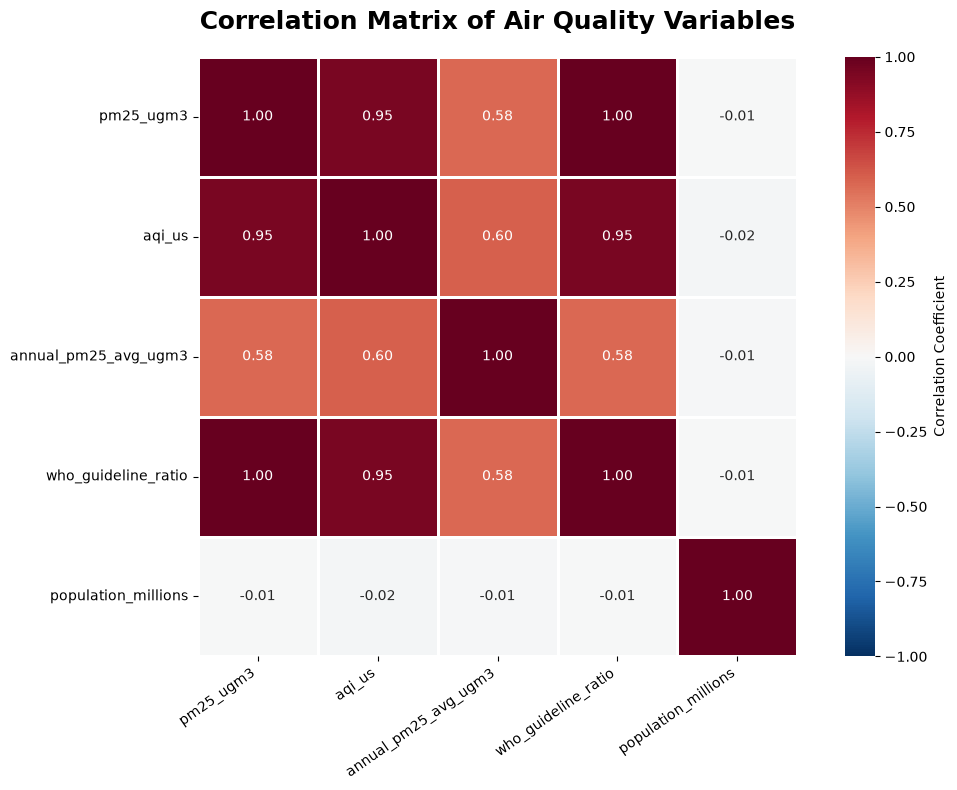

In [80]:
plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    linewidths=1,
    square=True,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0,
    cbar_kws={
        "label": "Correlation Coefficient"
    }
)

plt.title(
    "Correlation Matrix of Air Quality Variables",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xlabel("")
plt.ylabel("")

plt.xticks(
    rotation=35,
    ha="right"
)

plt.tight_layout()
plt.show()

In [81]:
# Convert correlation matrix into pairs

corr_pairs = (
    correlation_matrix
    .where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

corr_pairs.columns = [
    'Feature 1',
    'Feature 2',
    'Correlation'
]

corr_pairs = corr_pairs.sort_values(
    'Correlation',
    ascending=False
)

corr_pairs

,Feature 1,Feature 2,Correlation
3,pm25_ugm3,who_guideline_ratio,0.999996
1,pm25_ugm3,aqi_us,0.952428
8,aqi_us,who_guideline_ratio,0.952412
7,aqi_us,annual_pm25_avg_ugm3,0.597789
13,annual_pm25_avg_ugm3,who_guideline_ratio,0.577458
2,pm25_ugm3,annual_pm25_avg_ugm3,0.577457
19,who_guideline_ratio,population_millions,-0.005636
4,pm25_ugm3,population_millions,-0.005644
14,annual_pm25_avg_ugm3,population_millions,-0.008320
9,aqi_us,population_millions,-0.019079


In [ ]:
#Finding Strong positive relations
strong_positive = corr_pairs[
    corr_pairs['Correlation'] >= 0.70
]

print("Strong Positive Relationships:")
print(strong_positive)

Strong Positive Relationships:
   Feature 1            Feature 2  Correlation
3  pm25_ugm3  who_guideline_ratio     0.999996
1  pm25_ugm3               aqi_us     0.952428
8     aqi_us  who_guideline_ratio     0.952412


In [ ]:
#Finding strong negative relations
strong_negative = corr_pairs[
    corr_pairs['Correlation'] <= -0.70
]

print("Strong Negative Relationships:")
print(strong_negative)

Strong Negative Relationships:
Empty DataFrame
Columns: [Feature 1, Feature 2, Correlation]
Index: []


In [84]:
#Finding Moderate Relations
moderate_relationships = corr_pairs[
    (corr_pairs['Correlation'].abs() >= 0.30) &
    (corr_pairs['Correlation'].abs() < 0.70)
]

print("Moderate Relationships:")
print(moderate_relationships)

Moderate Relationships:
               Feature 1             Feature 2  Correlation
7                 aqi_us  annual_pm25_avg_ugm3     0.597789
13  annual_pm25_avg_ugm3   who_guideline_ratio     0.577458
2              pm25_ugm3  annual_pm25_avg_ugm3     0.577457


##DATA VISUALIZATION

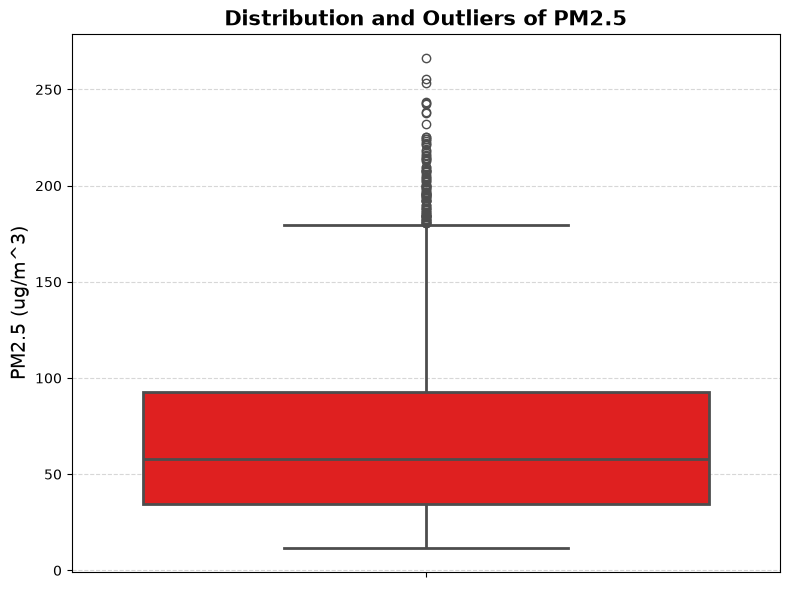

In [39]:
#Looking for outliers in pm25_ugm3 column
plt.figure(figsize= (8,6))
sns.boxplot(
    data= df,
    y= 'pm25_ugm3',
    color= 'Red',
    linewidth= 2.0,
    fliersize= 6
)
plt.title(
    'Distribution and Outliers of PM2.5',
    fontsize= 15,
    fontweight= 'bold'
)
plt.ylabel(
    'PM2.5 (ug/m^3)',
    fontsize= 14)
plt.grid(
    axis= 'y',
    linestyle= '--',
    alpha= 0.5
)
plt.tight_layout()
plt.show()

In [40]:
df.columns

Index(['year', 'month', 'month_name', 'city', 'province', 'region', 'latitude',
       'longitude', 'population_millions', 'pm25_ugm3', 'aqi_us',
       'aqi_category', 'annual_pm25_avg_ugm3', 'who_guideline_ratio',
       'is_smog_season', 'is_crop_burning_season', 'is_monsoon_season',
       'season', 'covid_lockdown_period', 'data_source', 'data_quality'],
      dtype='str')

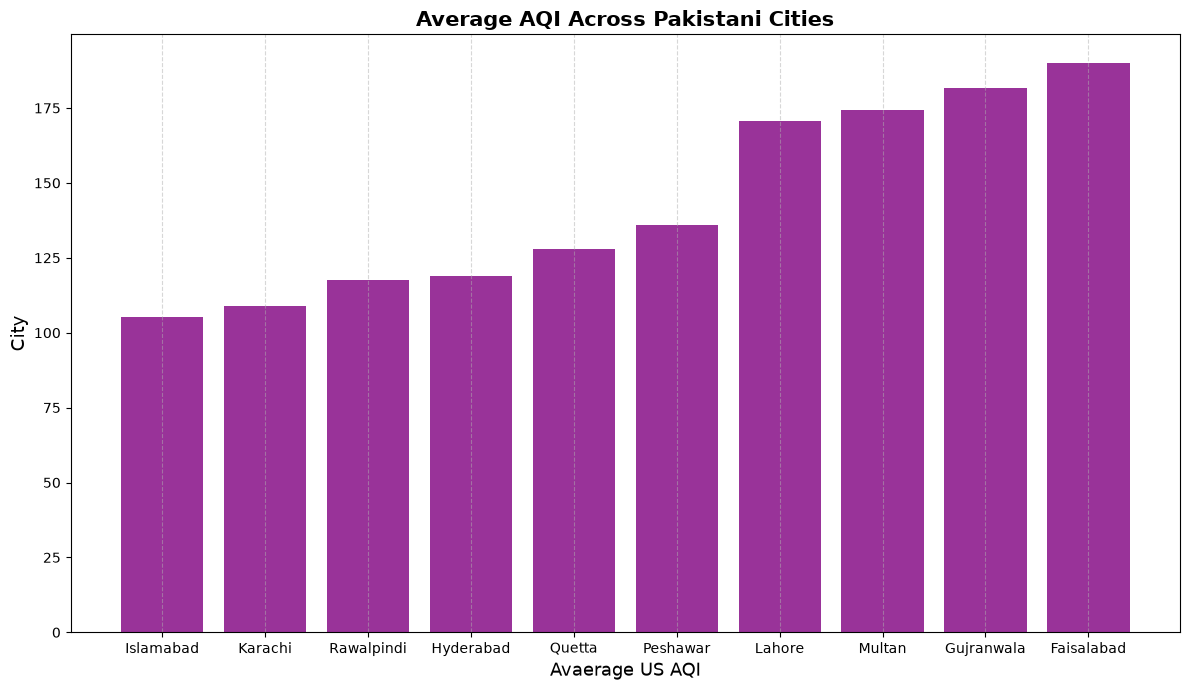

In [47]:
city_aqi= (
    df.groupby('city')['aqi_us']
    .mean()
    .sort_values()
)
plt.figure(figsize= (12,7))
plt.bar(
    city_aqi.index,
    city_aqi.values,
    alpha=0.8,
    color= 'purple',
    linewidth= 4
)
plt.title(
    'Average AQI Across Pakistani Cities',
    fontsize= 15,
    fontweight= 'bold'
)
plt.xlabel(
    'Avaerage US AQI',
    fontsize= 13
)
plt.ylabel(
    'City',
    fontsize= 13
)
plt.grid(
    axis= 'x',
    linestyle='--',
    alpha = 0.5
)
plt.tight_layout()
plt.show()


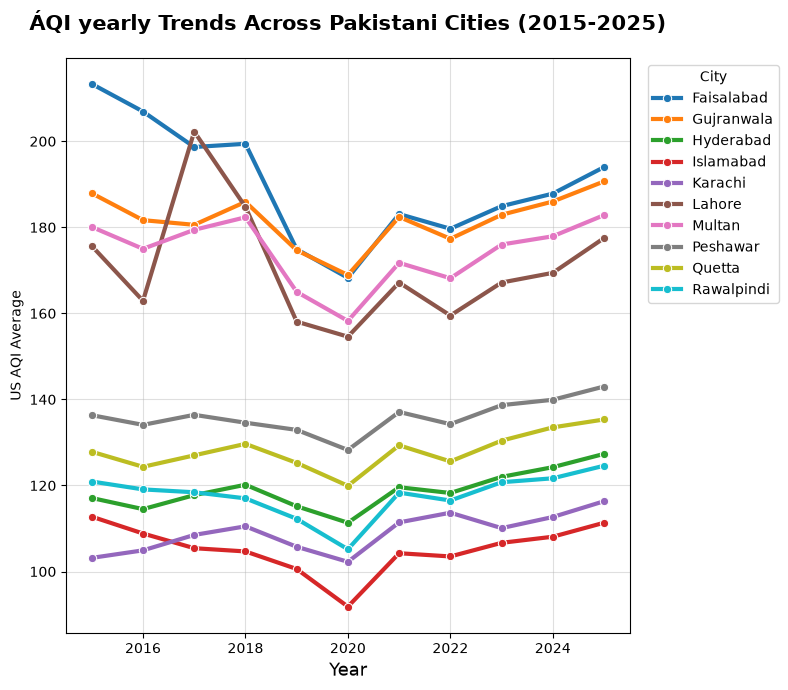

In [53]:
yearly_aqi= (
    df.groupby(['year','city'])['aqi_us']
    .mean()
    .reset_index()
)
plt.figure(figsize=(8,7))
sns.lineplot(
    data= yearly_aqi,
    x= 'year',
    y='aqi_us',
    hue= 'city',
    marker= 'o',
    linewidth= 3
)
plt.title(
    'ÁQI yearly Trends Across Pakistani Cities (2015-2025)',
    fontsize= 15,
    fontweight= 'bold',
    pad= 20
)
plt.xlabel(
    'Year',
    fontsize= 13
)
plt.ylabel(
    'US AQI Average'
)
plt.grid(
    axis='both',
    linestyle='-',
    alpha= 0.4
)
plt.legend(
    title="City",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

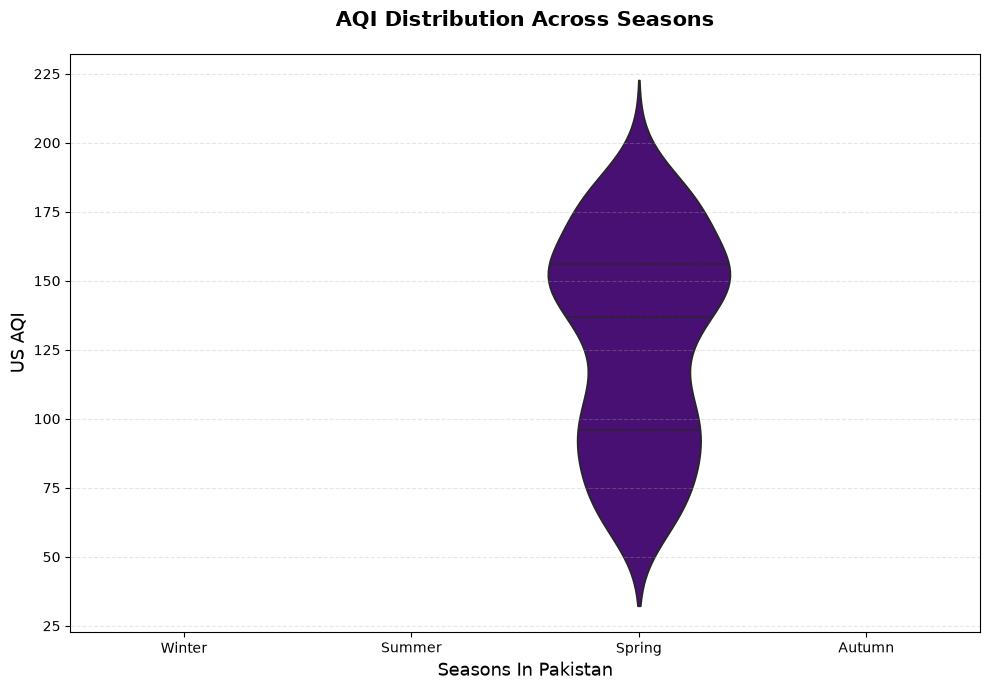

In [57]:
season_order= [
    'Winter',
    'Summer',
    'Spring',
    'Autumn'
]
plt.figure(figsize= (10,7))
sns.violinplot(
    data= df,
    x= 'season',
    y='aqi_us',
    order= season_order,
    inner= 'quartile',
    linewidth= 1.3,
    color= 'Indigo',
    
)
plt.title(
    'AQI Distribution Across Seasons',
    fontsize= 15, 
    fontweight='bold',
    pad= 20
)
plt.xlabel(
    'Seasons In Pakistan',
    fontsize= 13,
)
plt.ylabel(
    'US AQI',
    fontsize= 13,
)
plt.grid(
    axis= 'y',
    linestyle= '--',
    alpha= 0.3
)
plt.tight_layout()
plt.show()

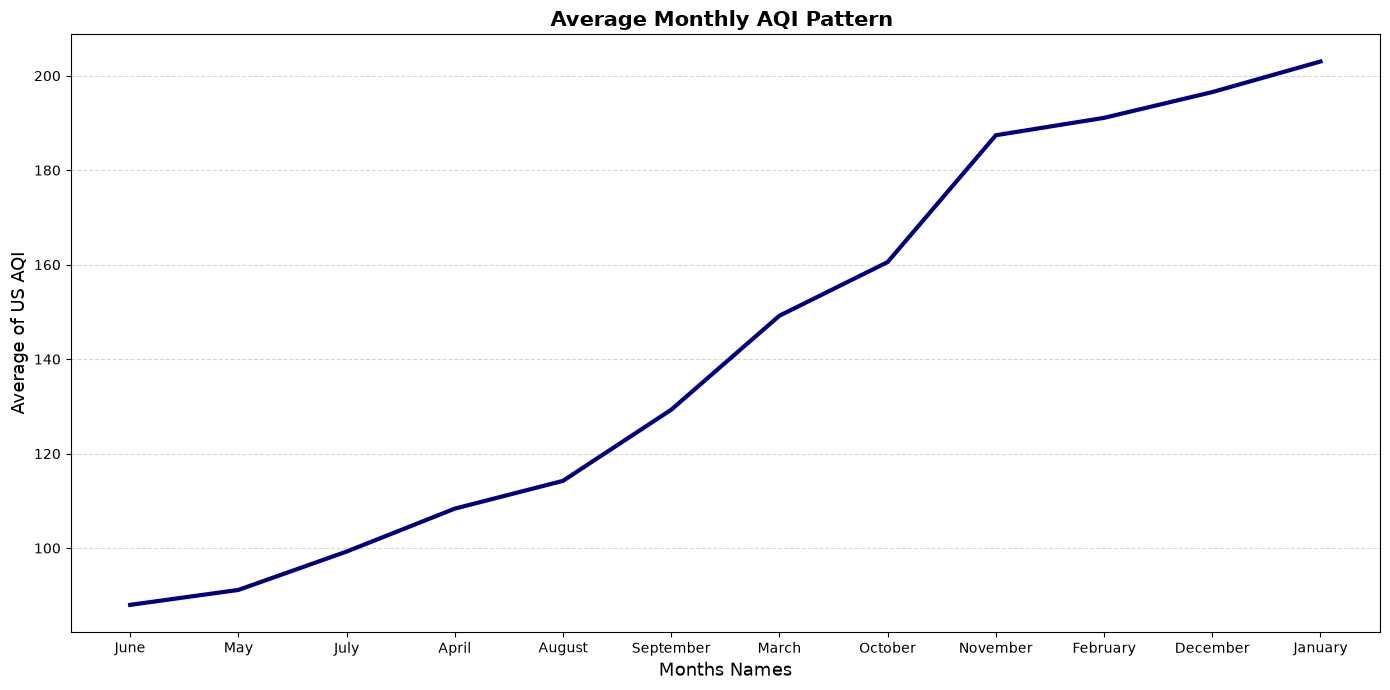

In [62]:
monthly_aqi=(
    df.groupby(['month', 'month_name']) ['aqi_us']
    .mean()
    .sort_values()
    .reset_index()
)
plt.figure(figsize=(14,7))
sns.lineplot(
    data= monthly_aqi,
    x= 'month_name',
    y= 'aqi_us',
    markers= 'o',
    linewidth= 3,
    color= 'navy'
)
plt.title(
    'Average Monthly AQI Pattern ' ,
    fontsize= 15, 
    fontweight= 'bold'
)
plt.xlabel(
    'Months Names',
    fontsize= 13,
)
plt.ylabel(
    'Average of US AQI',
    fontsize= 13
)
plt.grid(
    axis= 'y',
    linestyle= '--',
    alpha= 0.5
)
plt.tight_layout()
plt.show()

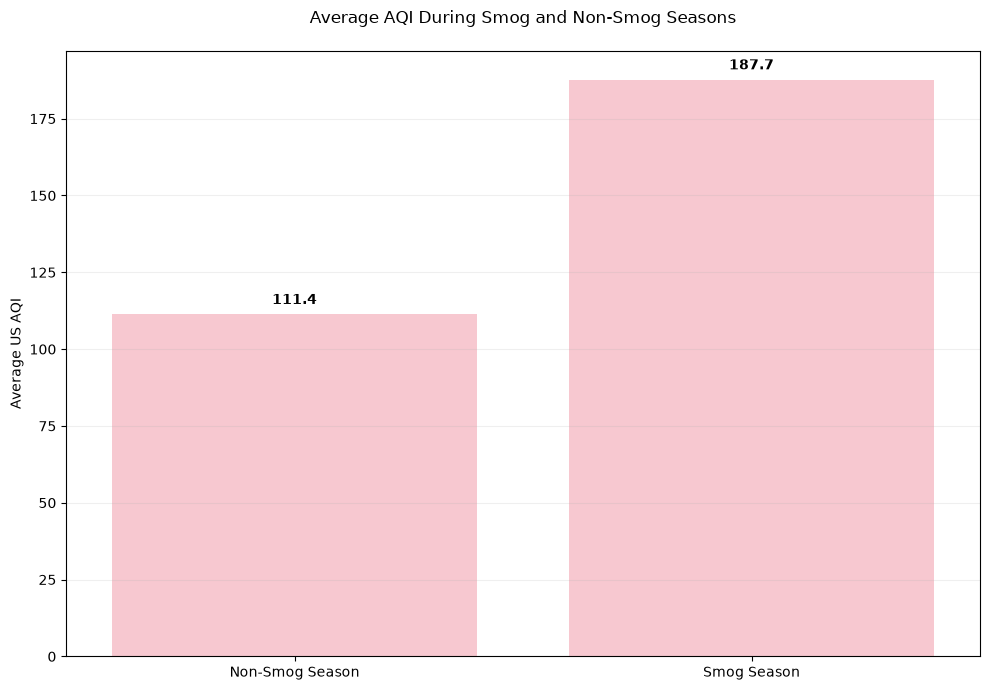

In [64]:
smog_aqi = (
    df.groupby("is_smog_season")["aqi_us"]
    .mean()
    .reset_index()
)

smog_aqi["Period"] = smog_aqi["is_smog_season"].map({
    0: "Non-Smog Season",
    1: "Smog Season"
})

plt.figure(figsize=(10, 7))

bars = sns.barplot(
    data=smog_aqi,
    x="Period",
    y="aqi_us",
    color= 'Pink'
)

plt.title(
    "Average AQI During Smog and Non-Smog Seasons",
    pad=20
)

plt.xlabel("")
plt.ylabel("Average US AQI")

for container in bars.containers:
    bars.bar_label(
        container,
        fmt="%.1f",
        padding=5,
        fontweight="bold"
    )

plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

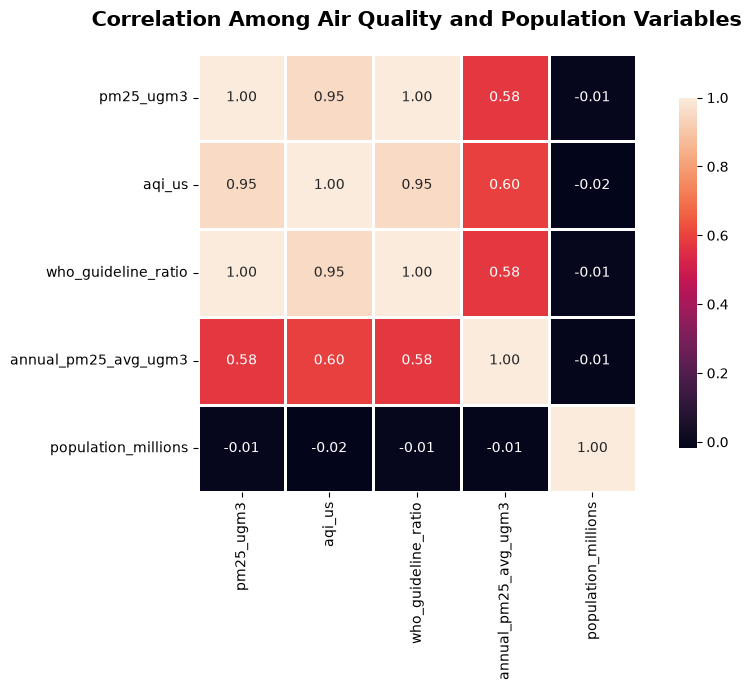

In [65]:
corr_columns= [
    'pm25_ugm3',
    'aqi_us',
    'who_guideline_ratio',
    'annual_pm25_avg_ugm3',
    'population_millions'
]
corr= df[corr_columns].corr()
plt.figure(figsize=(10,7))
sns.heatmap(
    corr,
    annot= True,
    fmt= '.2f',
    square= True,
    linewidth= 0.8,
    cbar_kws= {'shrink': 0.8}
)
plt.title(
    'Correlation Among Air Quality and Population Variables',
    fontsize= 15,
    fontweight= 'bold',
    pad= 20
)
plt.tight_layout()
plt.show()

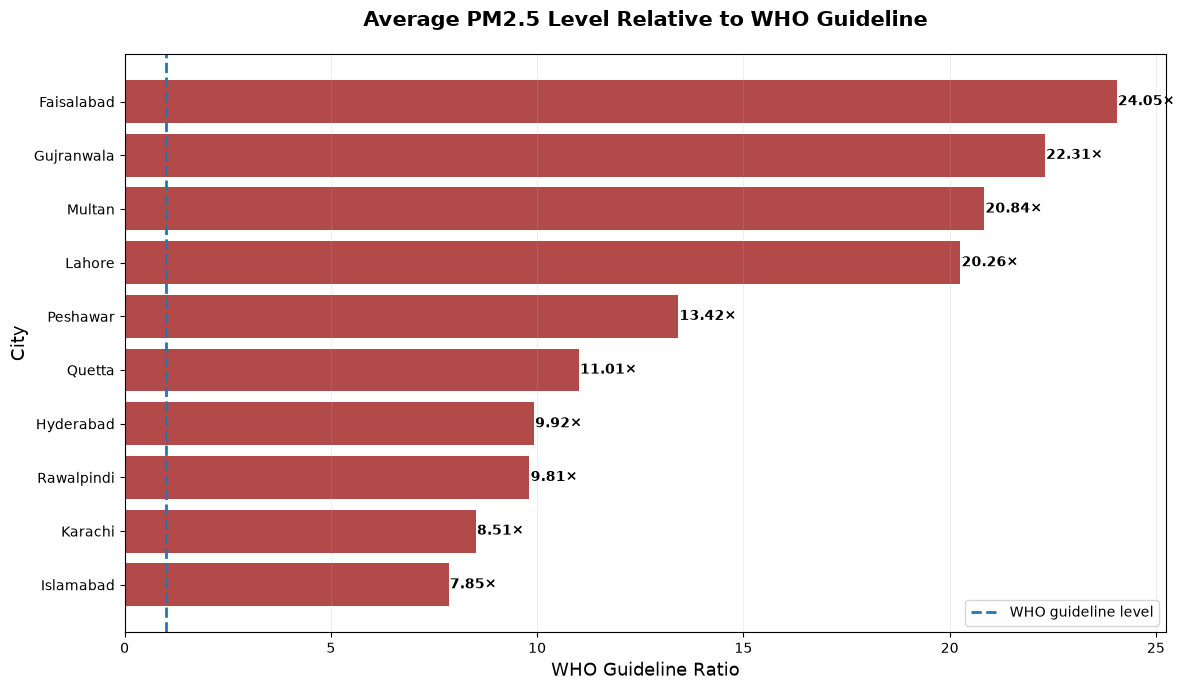

In [69]:
who_city = (
    df.groupby("city")["who_guideline_ratio"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(12, 7))

bars = plt.barh(
    who_city.index,
    who_city.values,
    alpha=0.85,
    color= 'brown'
)

plt.axvline(
    1,
    linestyle="--",
    linewidth=2,
    label="WHO guideline level"
)

plt.title(
    "Average PM2.5 Level Relative to WHO Guideline",
    fontsize= 15,
    fontweight= 'bold',
    pad=20
)

plt.xlabel("WHO Guideline Ratio", fontsize= 13)
plt.ylabel("City", fontsize= 13)

for bar in bars:
    value = bar.get_width()

    plt.text(
        value + 0.03,
        bar.get_y() + bar.get_height()/2,
        f"{value:.2f}×",
        va="center",
        fontweight="bold"
    )

plt.legend()
plt.grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()

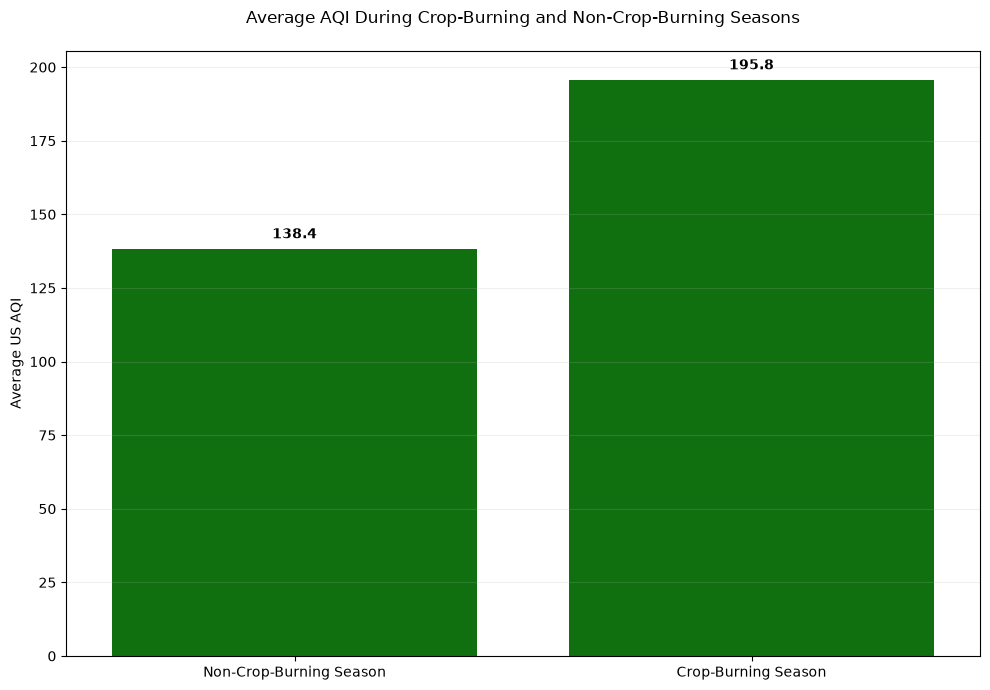

In [71]:
crop_aqi = (
    df.groupby("is_crop_burning_season")["aqi_us"]
    .mean()
    .reset_index()
)

crop_aqi["Period"] = crop_aqi["is_crop_burning_season"].map({
    0: "Non-Crop-Burning Season",
    1: "Crop-Burning Season"
})

plt.figure(figsize=(10, 7))

ax = sns.barplot(
    data=crop_aqi,
    x="Period",
    y="aqi_us",
    color= 'green'
)

plt.title(
    "Average AQI During Crop-Burning and Non-Crop-Burning Seasons",
    pad=20
)

plt.xlabel("")
plt.ylabel("Average US AQI")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f",
        padding=5,
        fontweight="bold"
    )

plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

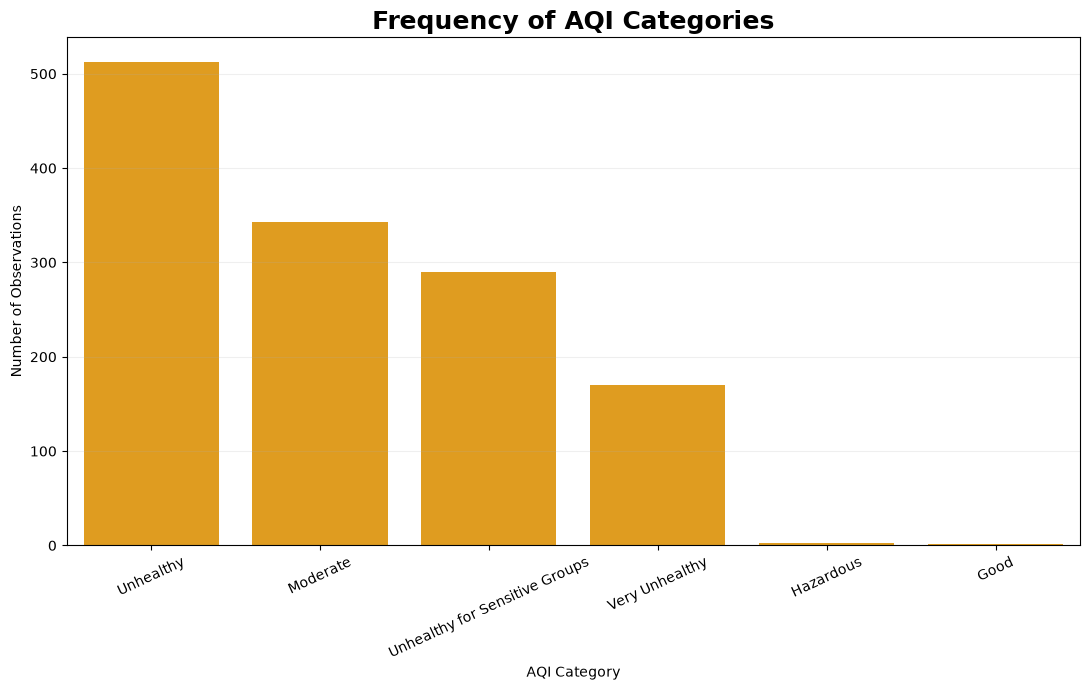

In [72]:
plt.figure(figsize=(11, 7))

order = df["aqi_category"].value_counts().index

sns.countplot(
    data=df,
    x="aqi_category",
    order=order,
    color= 'orange'
)

plt.title(
    "Frequency of AQI Categories",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("AQI Category")
plt.ylabel("Number of Observations")

plt.xticks(rotation=25)
plt.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

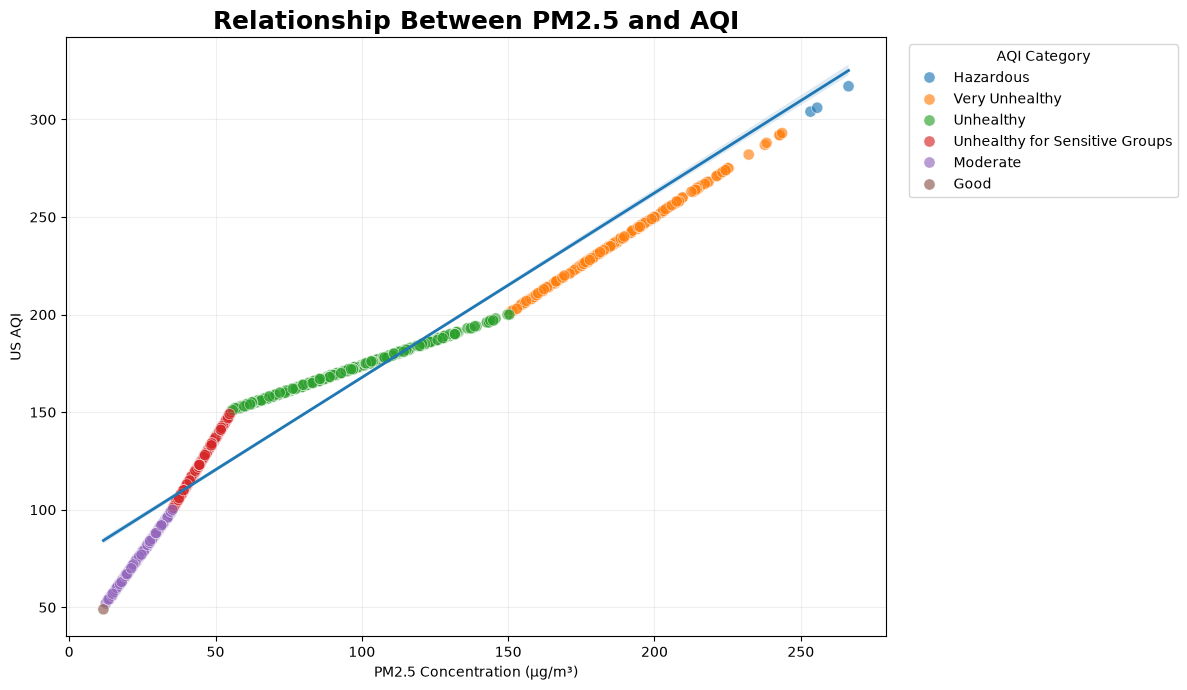

In [76]:
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df,
    x="pm25_ugm3",
    y="aqi_us",
    hue="aqi_category",
    s=65,
    alpha=0.65,
    edgecolor="white",
    linewidth=0.5
)

sns.regplot(
    data=df,
    x="pm25_ugm3",
    y="aqi_us",
    scatter=False,
    line_kws={"linewidth": 2}
)

plt.title(
    "Relationship Between PM2.5 and AQI",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("PM2.5 Concentration (µg/m³)")
plt.ylabel("US AQI")

plt.legend(
    title="AQI Category",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

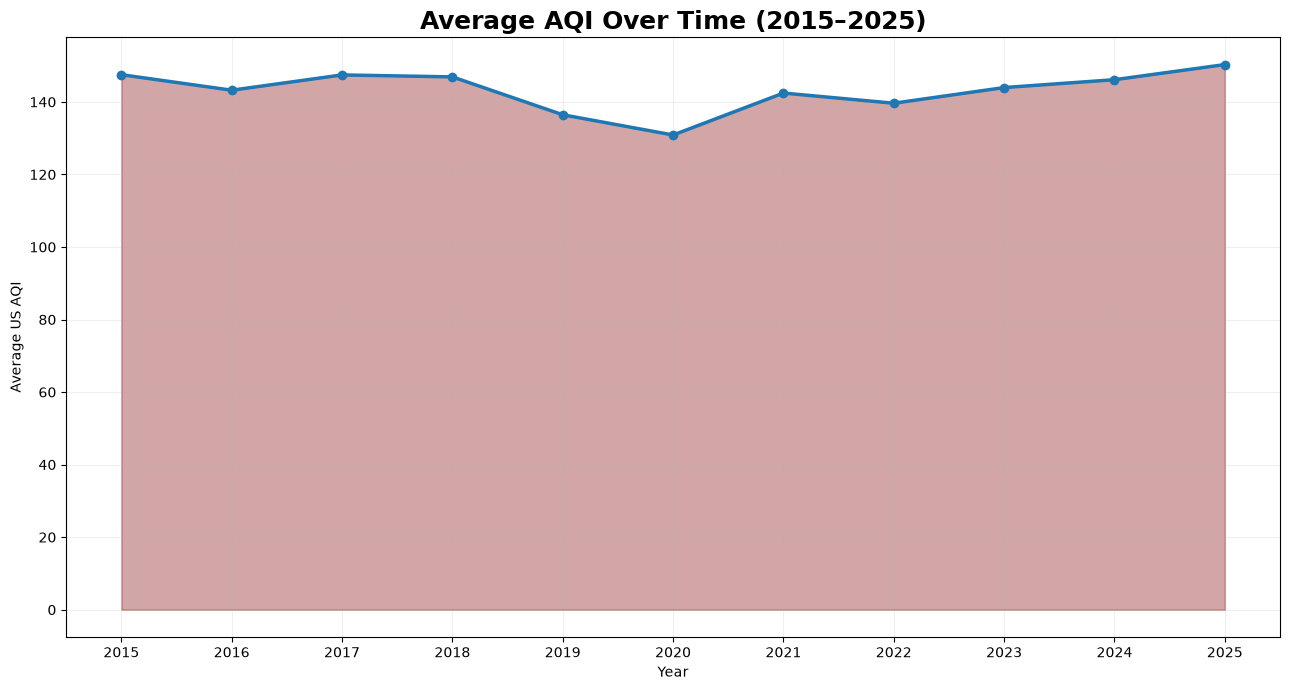

In [78]:
yearly_aqi = (
    df.groupby("year")["aqi_us"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(13, 7))

plt.fill_between(
    yearly_aqi["year"],
    yearly_aqi["aqi_us"],
    alpha=0.35,
    color= 'maroon'
)

plt.plot(
    yearly_aqi["year"],
    yearly_aqi["aqi_us"],
    marker="o",
    linewidth=2.5
)

plt.title(
    "Average AQI Over Time (2015–2025)",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("Average US AQI")

plt.xticks(yearly_aqi["year"])
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

##   BUSINESS INSIGHTS

Based on the EDA, correlation analysis, and grouped comparisons above, the following 15 insights summarize the key patterns found in the Pakistan Air Quality (2015–2025) dataset.

1. **Chronic, not occasional, pollution problem** – Across all 1,320 monthly records, the average AQI is 143.2 ("Unhealthy" on the US EPA scale). 52.0% of all observations fall in the Unhealthy/Very Unhealthy/Hazardous range, while only 26.1% are Good/Moderate — air quality is unsafe for roughly half of all city-months, not just during rare spikes.

2. **Industrial Punjab cities dominate pollution** – Faisalabad (190.1 avg AQI), Gujranwala (181.7), Multan (174.2), and Lahore (170.8) are the four most polluted cities, all located in Punjab's industrial belt.

3. **Population size does not drive pollution** – The correlation between population and AQI is effectively zero (r = -0.019). Karachi (16.1M) and Lahore (14.0M) are the largest cities, yet smaller industrial cities like Faisalabad (3.8M) and Gujranwala (2.3M) are far more polluted — pollution tracks industrial/geographic factors, not population.

4. **Nearly 2x gap between best and worst cities** – Faisalabad's average AQI (190.1) is 1.81x Islamabad's (105.3), an 84.8-point gap between the most and least polluted cities in the dataset.

5. **Winter smog season roughly doubles AQI** – Winter (Smog Season) AQI averages 196.9 vs. 98.2 in Summer/Monsoon — almost exactly a 2x seasonal swing.

6. **January is the worst month, June the best** – January averages 203.0 AQI vs. June's 88.0 — a 2.3x difference. The three worst months (Jan, Dec, Feb) form a consistent winter cluster.

7. **Crop-burning season adds a substantial penalty** – Average AQI during crop-burning months is 195.8 vs. 138.4 otherwise, a 41% jump, confirming agricultural burning materially worsens air quality.

8. **COVID lockdowns proved activity reduction works** – During lockdown periods, average AQI fell to 98.5 vs. 144.6 outside lockdowns — a 32% reduction, a natural experiment showing that cutting industrial/traffic activity measurably improves air quality.

9. **PM2.5 is the dominant driver of AQI** – PM2.5 and AQI correlate almost perfectly (r = 0.952), meaning fine particulate matter — not other pollutants — is what is driving Pakistan's poor AQI ratings.

10. **Extreme WHO guideline exceedance in industrial cities** – Faisalabad's PM2.5 averages 24.0x the WHO guideline (peaking at 53.3x in winter months); Multan, Gujranwala, and Lahore also average 20x+. Even Islamabad, the cleanest city, still averages 7.9x the WHO limit.

11. **Pollution is rising again post-COVID, now at an all-time high** – National average PM2.5 dropped to 59.0 µg/m³ in 2020 (COVID year) but climbed steadily to 80.1 µg/m³ by 2025 — its highest recorded level — showing pandemic-era gains have been fully reversed.

12. **Most extreme outliers cluster in Faisalabad and Lahore winters** – The five worst monthly readings (PM2.5 up to 266.3 µg/m³, AQI 317 "Hazardous") all occur in Faisalabad or Lahore during January, December, or November.

13. **Structural, mid-range pollution is the real issue, not rare disasters** – Only 1 "Good" and 3 "Hazardous" records exist out of 1,320. The dominant categories are "Unhealthy" (513 records) and "Unhealthy for Sensitive Groups" (290) — a chronic middle-tier problem rather than isolated catastrophic events.

14. **Monsoon rain measurably cleans the air** – AQI during monsoon months averages 114.9 vs. 151.4 in non-monsoon months, a ~24% reduction, confirming precipitation as a natural mitigating factor.

15. **No natural factor other than rain/lockdowns reduces pollution** – Moderate correlations (0.58–0.60) exist between city-level annual averages and monthly readings, but no strong negative correlations appear anywhere in the dataset — pollution only drops when there's deliberate intervention (rain, lockdown) rather than any built-in counterbalance.

16. **Provincial pattern reinforces the Punjab focus** – Punjab has by far the highest provincial average AQI (166.9) vs. Khyber Pakhtunkhwa (136.0), Balochistan (128.0), Sindh (113.9), and Islamabad Capital Territory (105.3) — confirming Punjab's industrial belt as the top intervention priority.

##  BUSINESS IMPROVEMENT RECOMMENDATIONS

1. **Concentrate intervention resources on the "Big Four" industrial Punjab cities (Faisalabad, Gujranwala, Multan, Lahore).**
   *Why:* These four cities consistently top the AQI rankings, and population size shows no correlation with pollution (r = -0.019), so budget allocation should follow the pollution data rather than population — targeting these four yields the highest health-impact return per resource spent.

2. **Design and enforce time-boxed seasonal interventions for October–February rather than uniform year-round policy.**
   *Why:* Winter AQI (196.9) is roughly double Summer/Monsoon AQI (98.2), and crop-burning season alone adds a 41% AQI penalty. A synchronized push (crop-residue burning enforcement, traffic restrictions, industrial emission caps) concentrated in this five-month window would be far more cost-effective than spreading the same budget evenly across the year.

3. **Pilot controlled activity-reduction measures (e.g., odd-even vehicle schemes, temporary industrial throttling) in the worst cities during peak smog weeks.**
   *Why:* The COVID lockdown period is a real-world proof of concept — AQI fell 32% (144.6 → 98.5) when activity was reduced. This shows a similar, less disruptive, deliberately-scheduled intervention could achieve a measurable improvement without a full economic shutdown.

4. **Treat the 2020–2025 upward trend as an urgent renewal signal, not a stable baseline.**
   *Why:* National PM2.5 fell to 59.0 µg/m³ in 2020 but has climbed every year since to an all-time high of 80.1 µg/m³ in 2025. Without renewed enforcement, the pandemic-era improvement will continue to erode and pollution will keep exceeding pre-2020 levels.

5. **Target health and consumer-protection services (respiratory care, air-purifier retail, health insurance add-ons) specifically at Faisalabad, Gujranwala, Multan, and Lahore during November–February.**
   *Why:* This is exactly where and when WHO-guideline exceedance peaks (20x–24x on average, up to 53x), making it the most identifiable and time-bound target segment — a level of need that cities like Islamabad and Karachi do not share.

6. **Benchmark and replicate whatever policy/planning differences exist in Islamabad and Karachi, the two consistently lowest-AQI cities.**
   *Why:* Karachi has the largest population in the dataset (16.1M) yet ranks among the cleanest, proving that high population and high pollution are not linked. Studying what these two cities do differently (industrial zoning, traffic management, fuel standards) could inform transferable interventions for the higher-AQI Punjab cities.